# Détection d'anomalies avec un auto-encodeur

Première idée que je voulais tester : entraîner un auto-encodeur uniquement sur des exemples
sains, et me servir de l'erreur de reconstruction pour repérer les anomalies. Si le modèle
n'a vu que du "normal", il devrait mal reconstruire ce qui sort de l'ordinaire.

Données : Breast Cancer Wisconsin (30 variables, 569 patients).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, f1_score, roc_auc_score, average_precision_score, recall_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

## Données

Petit rappel sur les labels de scikit-learn : 0 = malignant (tumeur), 1 = benign (sain).
Je vais inverser cette logique juste après pour raisonner en anomalie.

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print(data.target_names)
print("X:", X.shape)

['malignant' 'benign']
X: (569, 30)


In [3]:
X_df = pd.DataFrame(X, columns=data.feature_names)
X_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

## Préparation

Je n'entraîne que sur les sains. Le test contient des sains laissés de côté + toutes les
tumeurs. Pour ce notebook je repasse en 0 = sain, 1 = anomalie.

In [5]:
X_sain = X[y == 1]
X_anomalies = X[y == 0]

X_train_sain, X_test_sain = train_test_split(X_sain, test_size=0.3, random_state=SEED)

X_test = np.vstack((X_test_sain, X_anomalies))
y_test = np.hstack([np.zeros(len(X_test_sain)), np.ones(len(X_anomalies))])

print("train (sains):", X_train_sain.shape)
print("test:", X_test.shape, "-", int(y_test.sum()), "anomalies")

train (sains): (249, 30)
test: (320, 30) - 212 anomalies


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sain)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()
y_test_tensor = torch.from_numpy(y_test).long()

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

## Le modèle

Auto-encodeur tout simple, latent de dimension 2 pour pouvoir le visualiser ensuite.

In [7]:
class Encodeur(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 14),
            nn.LeakyReLU(),
            nn.Linear(14, 6),
            nn.LeakyReLU(),
            nn.Linear(6, latent_dim),
        )
    def forward(self, x):
        return self.net(x)

class Decodeur(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 6),
            nn.LeakyReLU(),
            nn.Linear(6, 14),
            nn.LeakyReLU(),
            nn.Linear(14, 30),
        )
    def forward(self, z):
        return self.net(z)

class AutoEncodeur(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

## Entraînement

20 0.8962
40 0.7547
60 0.655
80 0.5105


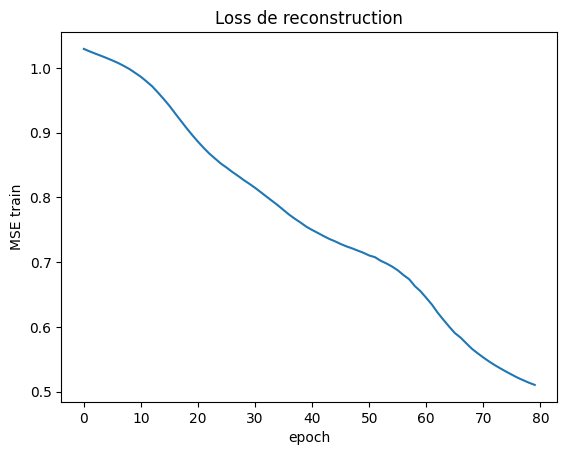

In [8]:
set_seed()
ae = AutoEncodeur(latent_dim=2)

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

losses = []
for epoch in range(80):
    ae.train()
    running = 0.0
    for (xb,) in train_loader:
        optimizer.zero_grad()
        out = ae(xb)
        loss = loss_fn(out, xb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    epoch_loss = running / len(train_loader.dataset)
    losses.append(epoch_loss)
    scheduler.step(epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(epoch + 1, round(epoch_loss, 4))

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("MSE train"); plt.title("Loss de reconstruction")
plt.savefig("figures/ae_loss.png", dpi=130, bbox_inches="tight")
plt.show()

## Erreurs de reconstruction

On calcule la MSE par patient sur le test. Ce que j'espère voir : des erreurs plus élevées
côté tumeurs.

erreur moyenne sains    : 0.5292
erreur moyenne anomalies: 5.4667


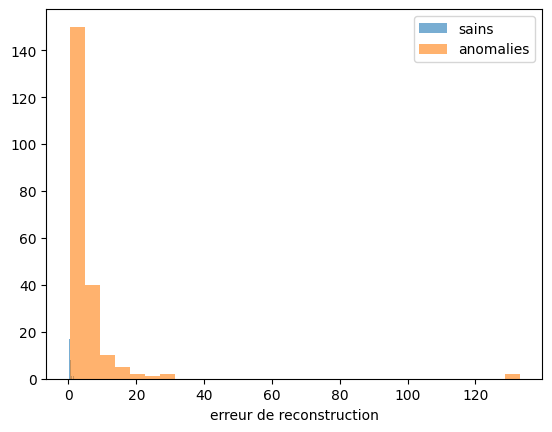

In [9]:
ae.eval()
errors = []
y_true = []
with torch.no_grad():
    for xb, yb in test_loader:
        out = ae(xb)
        mse = torch.mean((xb - out) ** 2, dim=1)
        errors.extend(mse.numpy())
        y_true.extend(yb.numpy())

errors = np.array(errors)
y_true = np.array(y_true)

print("erreur moyenne sains    :", round(errors[y_true == 0].mean(), 4))
print("erreur moyenne anomalies:", round(errors[y_true == 1].mean(), 4))

plt.hist(errors[y_true == 0], bins=30, alpha=0.6, label="sains")
plt.hist(errors[y_true == 1], bins=30, alpha=0.6, label="anomalies")
plt.xlabel("erreur de reconstruction"); plt.legend()
plt.savefig("figures/reconstruction_hist.png", dpi=130, bbox_inches="tight")
plt.show()

## Espace latent

Comme le latent est en 2D, on peut le tracer directement.

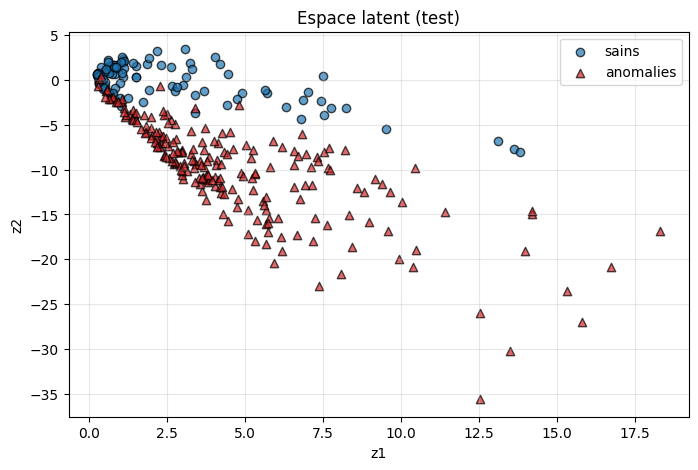

In [10]:
ae.eval()
zs, ys = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        zs.append(ae.encodeur(xb).numpy())
        ys.append(yb.numpy())
Z = np.vstack(zs)
Y = np.concatenate(ys)

plt.figure(figsize=(8, 5))
plt.scatter(Z[Y == 0, 0], Z[Y == 0, 1], c="tab:blue", alpha=0.7, edgecolors="k", label="sains")
plt.scatter(Z[Y == 1, 0], Z[Y == 1, 1], c="tab:red", alpha=0.7, edgecolors="k", marker="^", label="anomalies")
plt.xlabel("z1"); plt.ylabel("z2"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Espace latent (test)")
plt.savefig("figures/latent_space.png", dpi=130, bbox_inches="tight")
plt.show()

## Choix du seuil

Le score continu (erreur de reconstruction) doit devenir une décision. Je teste deux façons
de fixer le seuil, et pour comparer honnêtement je coupe le test en deux : une moitié sert à
régler le seuil, l'autre sert de test final. Les deux méthodes sont jugées sur la même moitié.

- seuil non supervisé : 95e percentile des erreurs sur le train (que des sains)
- seuil calibré : celui qui maximise le F1 sur la moitié validation

In [11]:
errors_val, errors_test, y_val, y_test_final = train_test_split(
    errors, y_true, test_size=0.5, stratify=y_true, random_state=SEED)

In [12]:
# seuil non supervisé : percentile sur les erreurs du train
train_errors = []
with torch.no_grad():
    for (xb,) in train_loader:
        out = ae(xb)
        train_errors.extend(torch.mean((xb - out) ** 2, dim=1).numpy())
train_errors = np.array(train_errors)

seuil_stat = np.percentile(train_errors, 95)
pred_stat = (errors_test >= seuil_stat).astype(int)

In [13]:
# seuil calibré par recherche sur la moitié validation
grid = np.linspace(errors_val.min(), errors_val.max(), 500)
best_f1, seuil_grid = -1, grid[0]
for t in grid:
    f = f1_score(y_val, (errors_val >= t).astype(int), zero_division=0)
    if f > best_f1:
        best_f1, seuil_grid = f, t

pred_grid = (errors_test >= seuil_grid).astype(int)

## Comparaison

ROC-AUC et PR-AUC ne dépendent pas du seuil. Le rappel sur les anomalies m'intéresse
particulièrement : en médical, rater une tumeur est plus grave qu'une fausse alerte.

In [14]:
print("ROC-AUC:", round(roc_auc_score(y_test_final, errors_test), 3))
print("PR-AUC :", round(average_precision_score(y_test_final, errors_test), 3))
print()

print("seuil non supervise (95e perc.) =", round(seuil_stat, 3))
print("F1:", round(f1_score(y_test_final, pred_stat), 3),
      "| rappel anomalies:", round(recall_score(y_test_final, pred_stat), 3))
print(classification_report(y_test_final, pred_stat, target_names=["sain", "anomalie"]))

print("seuil calibre (grid F1) =", round(seuil_grid, 3), "(F1 val =", round(best_f1, 3), ")")
print("F1:", round(f1_score(y_test_final, pred_grid), 3),
      "| rappel anomalies:", round(recall_score(y_test_final, pred_grid), 3))
print(classification_report(y_test_final, pred_grid, target_names=["sain", "anomalie"]))

ROC-AUC: 0.962
PR-AUC : 0.979

seuil non supervise (95e perc.) = 1.22
F1: 0.89 | rappel anomalies: 0.84
              precision    recall  f1-score   support

        sain       0.74      0.91      0.82        54
    anomalie       0.95      0.84      0.89       106

    accuracy                           0.86       160
   macro avg       0.84      0.87      0.85       160
weighted avg       0.88      0.86      0.87       160

seuil calibre (grid F1) = 0.587 (F1 val = 0.902 )
F1: 0.925 | rappel anomalies: 0.991
              precision    recall  f1-score   support

        sain       0.97      0.70      0.82        54
    anomalie       0.87      0.99      0.93       106

    accuracy                           0.89       160
   macro avg       0.92      0.85      0.87       160
weighted avg       0.90      0.89      0.89       160



## Bilan

Ça marche dans le bon sens (les tumeurs se reconstruisent moins bien) mais ça reste en
dessous d'un modèle supervisé, ce qui est logique vu que le modèle n'a jamais vu d'anomalie.
L'avantage, c'est qu'on n'a besoin d'aucun label d'anomalie. La suite (notebook 02) réutilise
le même encodeur, mais comme pré-entraînement pour classer.